# 🥗 Personalized Nutrition Recommender using Reinforcement Learning
**Author:** Zahra El Ghourani | **Supervisor:** Dr. Abbas Rammal


## Cell 1 — Imports & Seeds

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random, ast, warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
print('✅ Ready | Device:', 'cuda' if torch.cuda.is_available() else 'cpu')

✅ Ready | Device: cpu


## Cell 2 — Mount Drive

In [16]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive mounted')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted


## Cell 3 — Diet Protocols (17 types)

In [17]:
DIET_PROTOCOLS = {
    'balanced':       {'protein_pct':0.25,'carb_pct':0.50,'fat_pct':0.25,'cal_target':2000},
    'low_calorie':    {'protein_pct':0.30,'carb_pct':0.45,'fat_pct':0.25,'cal_target':1400},
    'low_carb':       {'protein_pct':0.35,'carb_pct':0.20,'fat_pct':0.45,'cal_target':1800},
    'ketogenic':      {'protein_pct':0.25,'carb_pct':0.05,'fat_pct':0.70,'cal_target':1800},
    'high_protein':   {'protein_pct':0.45,'carb_pct':0.20,'fat_pct':0.35,'cal_target':2200},
    'low_fat':        {'protein_pct':0.30,'carb_pct':0.55,'fat_pct':0.15,'cal_target':1800},
    'low_cholesterol':{'protein_pct':0.25,'carb_pct':0.55,'fat_pct':0.20,'cal_target':2000},
    'gluten_free':    {'protein_pct':0.25,'carb_pct':0.50,'fat_pct':0.25,'cal_target':2000},
    'lactose_free':   {'protein_pct':0.25,'carb_pct':0.50,'fat_pct':0.25,'cal_target':2000},
    'dash':           {'protein_pct':0.20,'carb_pct':0.55,'fat_pct':0.25,'cal_target':2000},
    'atkins':         {'protein_pct':0.40,'carb_pct':0.10,'fat_pct':0.50,'cal_target':1800},
    'zone':           {'protein_pct':0.30,'carb_pct':0.40,'fat_pct':0.30,'cal_target':2000},
    'south_beach':    {'protein_pct':0.30,'carb_pct':0.45,'fat_pct':0.25,'cal_target':1800},
    'mediterranean':  {'protein_pct':0.20,'carb_pct':0.50,'fat_pct':0.30,'cal_target':2000},
    'prudent':        {'protein_pct':0.25,'carb_pct':0.55,'fat_pct':0.20,'cal_target':2000},
    'vegan':          {'protein_pct':0.20,'carb_pct':0.55,'fat_pct':0.25,'cal_target':2000},
    'carb_cycle':     {'protein_pct':0.375,'carb_pct':0.35,'fat_pct':0.30,'cal_target':2200},
}
DIET_NAMES  = list(DIET_PROTOCOLS.keys())
N_DIETS     = len(DIET_NAMES)
CUISINES    = ['lebanese','mediterranean','western','asian','mexican']
N_CUISINES  = len(CUISINES)
ALLERGENS   = ['gluten','dairy','nuts','eggs','shellfish','soy','fish']
print(f'✅ {N_DIETS} diet protocols | {N_CUISINES} cuisines')

✅ 17 diet protocols | 5 cuisines


## Cell 4 — Load & Preprocess ALL Recipes

In [18]:
print('Loading Food.com dataset...')
df_raw = pd.read_csv('/content/drive/MyDrive/Recipes/RAW_recipes.csv')
print(f'Raw: {len(df_raw):,} recipes')

def parse_nutrition(s):
    try:
        v = ast.literal_eval(s)
        return float(v[0]),float(v[4]),float(v[6]),float(v[1]),float(v[2]),float(v[3])
    except: return None,None,None,None,None,None

def parse_list(s):
    try:    return ast.literal_eval(s)
    except: return []

df_raw[['calories','protein','carbs','fat','sugar','sodium']] = pd.DataFrame(
    df_raw['nutrition'].apply(parse_nutrition).tolist(), index=df_raw.index)
df_raw['tags_list']        = df_raw['tags'].apply(parse_list)
df_raw['ingredients_list'] = df_raw['ingredients'].apply(parse_list)

# Filter valid nutrition
df = df_raw.dropna(subset=['calories','protein','carbs','fat','sugar','sodium'])
df = df[
    (df['calories']>=50) & (df['calories']<=1500) &
    (df['protein'] >=0)  & (df['protein'] <=150)  &
    (df['carbs']   >=0)  & (df['carbs']   <=200)  &
    (df['fat']     >=0)  & (df['fat']     <=120)  &
    (df['sugar']   >=0)  & (df['sodium']  >=0)
].copy().reset_index(drop=True)

# Cuisine classification
CUISINE_KW = {
    'lebanese':      ['lebanese','middle-eastern'],
    'mediterranean': ['greek','italian'],
    'western':       ['american','european','western'],
    'asian':         ['asian','chinese','japanese','thai','indian'],
    'mexican':       ['mexican'],
}
def classify_cuisine(tags):
    s = ' '.join(tags).lower()
    for c,kws in CUISINE_KW.items():
        if any(k in s for k in kws): return c
    return 'western'

# Diet classification
DIET_KW = {
    'vegan':['vegan'],'low_carb':['low-carb'],'high_protein':['high-protein'],
    'gluten_free':['gluten-free'],'lactose_free':['lactose'],
    'low_fat':['low-fat'],'low_calorie':['low-calorie'],
    'low_cholesterol':['low-cholesterol'],'dash':['low-sodium'],
}
def classify_diet(tags):
    s = ' '.join(tags).lower()
    for d,kws in DIET_KW.items():
        if any(k in s for k in kws): return d
    return 'balanced'

# Allergen detection
ALLERGEN_KW = {
    'gluten':   ['gluten','wheat','flour','bread','pasta'],
    'dairy':    ['dairy','milk','cheese','butter','cream','lactose'],
    'nuts':     ['nuts','peanut','almond','walnut','cashew'],
    'eggs':     ['eggs','egg'],
    'shellfish':['shellfish','shrimp','lobster','crab'],
    'soy':      ['soy','tofu','edamame'],
    'fish':     ['fish','salmon','tuna','cod'],
}
def detect_allergens(tags):
    s = ' '.join(tags).lower()
    return [a for a,kws in ALLERGEN_KW.items() if any(k in s for k in kws)]

def classify_meal_slot(tags):
    s = ' '.join(tags).lower()
    if any(k in s for k in ['breakfast','brunch','morning']): return 'breakfast'
    if any(k in s for k in ['lunch','salad','sandwich','soup']): return 'lunch'
    if any(k in s for k in ['snack','appetizer','dessert']): return 'snack'
    return 'dinner'

df['cuisine']          = df['tags_list'].apply(classify_cuisine)
df['diet_tag']         = df['tags_list'].apply(classify_diet)
df['allergens']        = df['tags_list'].apply(detect_allergens)
df['meal_slot']        = df['tags_list'].apply(classify_meal_slot)
df['ingredients_list'] = df['ingredients_list']

# Keep ALL recipes per cuisine (no 150 limit!)
food_db = df[['name','calories','protein','carbs','fat','sugar','sodium',
              'cuisine','diet_tag','allergens','meal_slot','ingredients_list']].copy().reset_index(drop=True)

print(f'\n✅ Full food database: {len(food_db):,} recipes')
print('Cuisine distribution:')
print(food_db['cuisine'].value_counts().to_string())

Loading Food.com dataset...
Raw: 231,637 recipes

✅ Full food database: 208,848 recipes
Cuisine distribution:
cuisine
western          187229
asian             10391
mediterranean      8842
lebanese           1878
mexican             508


## Cell 5 — Environment

In [19]:
class NutritionEnv:
    MEAL_SLOTS   = ['breakfast','lunch','dinner','snack']
    MAX_STEPS    = 4
    SODIUM_LIMIT = 1500.0
    SUGAR_LIMIT  = 50.0
    W_CAL=1.0; W_PROT=0.8; W_CARB=0.6; W_FAT=0.6
    W_SUGAR=0.5; W_NA=0.4; W_AL=999.0; W_DIV=2.0
    W_REPEAT = 20.0  # repeat penalty

    def __init__(self, food_db, randomize_profile=True, seed=42):
        self.food_db           = food_db.reset_index(drop=True)
        self.n_actions         = len(food_db)
        self.randomize_profile = randomize_profile
        self.rng               = np.random.default_rng(seed)
        self.state_dim         = 8 + N_DIETS + N_CUISINES + 2 + 3
        self.reset()

    def _compute_targets(self, diet, cal):
        p = DIET_PROTOCOLS[diet]
        return {'calories':cal,'protein':p['protein_pct']*cal/4,
                'carbs':p['carb_pct']*cal/4,'fat':p['fat_pct']*cal/9,
                'sodium':self.SODIUM_LIMIT,'sugar':self.SUGAR_LIMIT}

    def reset(self, fixed_profile=None):
        if fixed_profile:
            self.diet            = fixed_profile['diet']
            self.cuisine         = fixed_profile['cuisine']
            self.diabetic        = fixed_profile.get('diabetic', False)
            self.hypertensive    = fixed_profile.get('hypertensive', False)
            self.user_allergens  = fixed_profile.get('allergens', [])
            self.carb_cycle_day  = fixed_profile.get('carb_cycle_day','medium')
            cal                  = fixed_profile.get('cal_target', DIET_PROTOCOLS[self.diet]['cal_target'])
        else:
            self.diet            = DIET_NAMES[int(self.rng.integers(0,N_DIETS))]
            self.cuisine         = CUISINES[int(self.rng.integers(0,N_CUISINES))]
            self.diabetic        = bool(self.rng.random()<0.15)
            self.hypertensive    = bool(self.rng.random()<0.20)
            n_al                 = int(self.rng.integers(0,3))
            self.user_allergens  = list(self.rng.choice(ALLERGENS,n_al,replace=False)) if n_al>0 else []
            self.carb_cycle_day  = ['low','medium','high'][int(self.rng.integers(0,3))]
            cal                  = DIET_PROTOCOLS[self.diet]['cal_target'] + int(self.rng.integers(-100,100))

        self.targets         = self._compute_targets(self.diet, cal)
        self.consumed        = {'calories':0.,'protein':0.,'carbs':0.,'fat':0.,'sugar':0.,'sodium':0.}
        self.step_idx        = 0
        self.recommended_ids = []
        return self._get_state()

    def get_action_mask(self):
        mask = np.ones(self.n_actions, dtype=bool)
        # Block allergens
        for i,row in self.food_db.iterrows():
            if any(a in row['allergens'] for a in self.user_allergens):
                mask[i] = False
        # Block already recommended (repeat prevention)
        for idx in self.recommended_ids:
            mask[idx] = False
        # Fallback if all blocked
        if mask.sum() == 0:
            for i,row in self.food_db.iterrows():
                if not any(a in row['allergens'] for a in self.user_allergens):
                    mask[i] = True
        return mask

    def step(self, action):
        food = self.food_db.iloc[action]
        for n in ['calories','protein','carbs','fat','sugar','sodium']:
            self.consumed[n] += float(food[n])
        self.recommended_ids.append(action)
        self.step_idx += 1
        done   = self.step_idx >= self.MAX_STEPS
        reward = self._compute_reward(done)
        return self._get_state(), reward, done, {
            'food_name':    food['name'],
            'ingredients':  food['ingredients_list'],
            'cuisine':      food['cuisine'],
            'consumed':     dict(self.consumed),
            'targets':      dict(self.targets),
            'diet':         self.diet,
        }

    def _compute_reward(self, done):
        if any(a in self.food_db.iloc[self.recommended_ids[-1]]['allergens']
               for a in self.user_allergens):
            return -self.W_AL
        if not done:
            excess = max(0, self.consumed['calories'] - self.targets['calories'])
            return -0.01 * excess
        c,t   = self.consumed, self.targets
        r     = -self.W_CAL*abs(c['calories']-t['calories'])
        r    -= self.W_PROT*abs(c['protein'] -t['protein'])
        r    -= self.W_CARB*abs(c['carbs']   -t['carbs'])
        r    -= self.W_FAT *abs(c['fat']     -t['fat'])
        if self.diabetic:    r -= self.W_SUGAR*max(0,c['sugar'] -t['sugar'])
        if self.hypertensive:r -= self.W_NA  *max(0,c['sodium']-t['sodium'])
        r    += self.W_DIV * len(set(self.recommended_ids))
        if abs(c['calories']-t['calories']) < 0.10*t['calories']: r += 50.0
        if abs(c['protein'] -t['protein'])  < 0.10*t['protein']:  r += 30.0
        return r

    def _get_state(self):
        t,c    = self.targets, self.consumed
        remain = max(0,t['calories']-c['calories'])
        base   = np.array([
            c['calories']/3000., c['protein']/250., c['carbs']/400.,
            c['fat']/150., c['sugar']/100., c['sodium']/3000.,
            self.step_idx/self.MAX_STEPS, remain/max(1,t['calories'])
        ], dtype=np.float32)
        diet_oh    = np.zeros(N_DIETS,    dtype=np.float32); diet_oh[DIET_NAMES.index(self.diet)]   = 1.
        cuisine_oh = np.zeros(N_CUISINES, dtype=np.float32); cuisine_oh[CUISINES.index(self.cuisine)]= 1.
        health     = np.array([float(self.diabetic),float(self.hypertensive)],dtype=np.float32)
        cycle_oh   = np.zeros(3,dtype=np.float32); cycle_oh[['low','medium','high'].index(self.carb_cycle_day)]=1.
        return np.concatenate([base,diet_oh,cuisine_oh,health,cycle_oh])

print(f'✅ Environment defined | State dim: {8+N_DIETS+N_CUISINES+2+3}')

✅ Environment defined | State dim: 35


## Cell 6 — Agents (Rule-Based, Q-Learning, DQN)

In [20]:
class RuleBasedAgent:
    def __init__(self, food_db): self.food_db = food_db
    def select_action(self, env):
        mask   = env.get_action_mask()
        valid  = np.where(mask)[0]
        slots  = env.MAX_STEPS - env.step_idx
        c,t    = env.consumed, env.targets
        best,score = 0, float('inf')
        for i in valid:
            f = env.food_db.iloc[i]
            s = (1.0*(c['calories']+f['calories']-t['calories']/max(1,slots))**2 +
                 0.8*(c['protein'] +f['protein'] -t['protein'])**2 +
                 0.6*(c['carbs']   +f['carbs']   -t['carbs'])**2 +
                 0.6*(c['fat']     +f['fat']      -t['fat'])**2)
            if s < score: score,best = s,i
        return best

class QLearningAgent:
    def __init__(self,state_dim,n_actions,n_bins=8,lr=0.1,gamma=0.99,
                 epsilon_start=1.,epsilon_end=0.05,epsilon_decay=0.995,seed=42):
        self.n_actions=n_actions;self.n_bins=n_bins;self.lr=lr;self.gamma=gamma
        self.epsilon=epsilon_start;self.epsilon_end=epsilon_end;self.epsilon_decay=epsilon_decay
        self.rng=np.random.default_rng(seed);self.q_table={}
    def _disc(self,s):
        bins=np.linspace(0,1,self.n_bins+1)
        return tuple(int(np.clip(np.digitize(x,bins)-1,0,self.n_bins-1)) for x in s)
    def _q(self,k):
        if k not in self.q_table: self.q_table[k]=np.zeros(self.n_actions)
        return self.q_table[k]
    def select_action(self,state,mask=None,training=True):
        valid=np.where(mask)[0] if mask is not None else np.arange(self.n_actions)
        if training and self.rng.random()<self.epsilon: return int(self.rng.choice(valid))
        q=self._q(self._disc(state)).copy()
        if mask is not None: q[~mask]=-np.inf
        return int(np.argmax(q))
    def update(self,s,a,r,s_,done):
        sk,sk_=self._disc(s),self._disc(s_)
        q=self._q(sk);target=r if done else r+self.gamma*np.max(self._q(sk_))
        q[a]+=self.lr*(target-q[a])
    def decay_epsilon(self): self.epsilon=max(self.epsilon_end,self.epsilon*self.epsilon_decay)

class QNetwork(nn.Module):
    def __init__(self,sd,na,h=128):
        super().__init__()
        self.net=nn.Sequential(nn.Linear(sd,h),nn.ReLU(),nn.Linear(h,h),nn.ReLU(),nn.Linear(h,na))
    def forward(self,x): return self.net(x)

class DQNAgent:
    def __init__(self,state_dim,n_actions,lr=3e-4,gamma=0.99,
                 epsilon_start=1.,epsilon_end=0.05,epsilon_decay=0.995,
                 buffer_size=10000,batch_size=64,target_update_freq=100,seed=42):
        self.n_actions=n_actions;self.gamma=gamma;self.epsilon=epsilon_start
        self.epsilon_end=epsilon_end;self.epsilon_decay=epsilon_decay
        self.batch_size=batch_size;self.target_update_freq=target_update_freq
        self.steps=0;self.rng=np.random.default_rng(seed)
        self.device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.policy_net=QNetwork(state_dim,n_actions).to(self.device)
        self.target_net=QNetwork(state_dim,n_actions).to(self.device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()
        self.optimizer=optim.Adam(self.policy_net.parameters(),lr=lr)
        self.buffer=deque(maxlen=buffer_size)
    def select_action(self,state,mask=None,training=True):
        valid=np.where(mask)[0] if mask is not None else np.arange(self.n_actions)
        if training and self.rng.random()<self.epsilon: return int(self.rng.choice(valid))
        with torch.no_grad():
            q=self.policy_net(torch.FloatTensor(state).unsqueeze(0).to(self.device)).squeeze(0).cpu().numpy()
        if mask is not None: q[~mask]=-np.inf
        return int(np.argmax(q))
    def store(self,s,a,r,s_,d): self.buffer.append((s,a,r,s_,d))
    def train_step(self):
        if len(self.buffer)<self.batch_size: return
        batch=random.sample(self.buffer,self.batch_size)
        s,a,r,s_,d=zip(*batch)
        s=torch.FloatTensor(np.array(s)).to(self.device)
        a=torch.LongTensor(a).unsqueeze(1).to(self.device)
        r=torch.FloatTensor(r).unsqueeze(1).to(self.device)
        s_=torch.FloatTensor(np.array(s_)).to(self.device)
        d=torch.FloatTensor(d).unsqueeze(1).to(self.device)
        cq=self.policy_net(s).gather(1,a)
        with torch.no_grad():
            tq=r+self.gamma*self.target_net(s_).max(1)[0].unsqueeze(1)*(1-d)
        loss=nn.HuberLoss()(cq,tq)
        self.optimizer.zero_grad();loss.backward()
        nn.utils.clip_grad_norm_(self.policy_net.parameters(),1.0)
        self.optimizer.step();self.steps+=1
        if self.steps%self.target_update_freq==0:
            self.target_net.load_state_dict(self.policy_net.state_dict())
    def decay_epsilon(self): self.epsilon=max(self.epsilon_end,self.epsilon*self.epsilon_decay)

print('✅ All agents defined')

✅ All agents defined


## Cell 7 — Train All Agents

In [21]:
# Sample 300 recipes for training (optimal for Q-Learning)
food_db_train = food_db.sample(n=300, random_state=SEED).reset_index(drop=True)

train_env = NutritionEnv(food_db_train, randomize_profile=True, seed=SEED)
test_env  = NutritionEnv(food_db_train, randomize_profile=True, seed=SEED+1)
STATE_DIM = train_env.state_dim
N_ACTIONS = train_env.n_actions
print(f'✅ Training on {N_ACTIONS} recipes | State dim: {STATE_DIM}')

def train(agent, env, n_ep, name, is_dqn=False, is_rule=False):
    rewards = []
    print(f'\nTraining {name}...')
    print(f'{"Ep":>8} {"AvgReward":>12} {"Eps":>8}')
    print('-'*32)
    for ep in range(1,n_ep+1):
        state=env.reset();done=False;ep_r=0
        while not done:
            mask=env.get_action_mask()
            a = agent.select_action(env) if is_rule else agent.select_action(state,mask=mask,training=True)
            s_,r,done,_=env.step(a)
            if is_dqn: agent.store(state,a,r,s_,done);agent.train_step()
            elif not is_rule: agent.update(state,a,r,s_,done)
            state=s_;ep_r+=r
        if not is_rule: agent.decay_epsilon()
        rewards.append(ep_r)
        if ep%200==0:
            eps=agent.epsilon if not is_rule else 0
            print(f'{ep:>8} {np.mean(rewards[-50:]):>12.2f} {eps:>8.3f}')
    print(f'✅ {name} done')
    return rewards

rule_agent = RuleBasedAgent(food_db_user)
rb_rewards = train(rule_agent, train_env, 300, 'Rule-Based', is_rule=True)

ql_agent   = QLearningAgent(STATE_DIM, N_ACTIONS, n_bins=8, lr=0.1,
                             gamma=0.99, epsilon_start=1., epsilon_end=0.05,
                             epsilon_decay=0.995, seed=SEED)
ql_rewards = train(ql_agent, train_env, 3000, 'Q-Learning')

dqn_agent  = DQNAgent(STATE_DIM, N_ACTIONS, lr=3e-4, gamma=0.99,
                      epsilon_start=1., epsilon_end=0.05, epsilon_decay=0.995,
                      buffer_size=10000, batch_size=64,
                      target_update_freq=100, seed=SEED)
dqn_rewards= train(dqn_agent, train_env, 2000, 'DQN', is_dqn=True)

✅ Training on 300 recipes | State dim: 35

Training Rule-Based...
      Ep    AvgReward      Eps
--------------------------------
     200      -146.58    0.000
✅ Rule-Based done

Training Q-Learning...
      Ep    AvgReward      Eps
--------------------------------
     200      -708.01    0.367
     400      -732.33    0.135
     600      -731.78    0.050
     800      -714.16    0.050
    1000      -745.23    0.050
    1200      -634.28    0.050
    1400      -735.39    0.050
    1600      -667.45    0.050
    1800      -679.08    0.050
    2000      -663.40    0.050
    2200      -724.90    0.050
    2400      -720.80    0.050
    2600      -651.79    0.050
    2800      -682.37    0.050
    3000      -723.68    0.050
✅ Q-Learning done

Training DQN...
      Ep    AvgReward      Eps
--------------------------------
     200      -602.26    0.367
     400      -639.27    0.135
     600      -735.54    0.050
     800      -585.18    0.050
    1000      -722.91    0.050
    1200      

## Cell 8 — Evaluation

In [22]:
def evaluate(agent, env, n=100, is_rule=False):
    rewards,cal_gaps,prot_gaps,adhere,diversity=[],[],[],[],[]
    for _ in range(n):
        state=env.reset(); done=False; ep_r=0
        while not done:
            mask=env.get_action_mask()
            a=agent.select_action(env) if is_rule else agent.select_action(state,mask=mask,training=False)
            state,r,done,info=env.step(a);ep_r+=r
        c,t=info['consumed'],info['targets']
        rewards.append(ep_r)
        cal_gaps.append(abs(c['calories']-t['calories']))
        prot_gaps.append(abs(c['protein']-t['protein']))
        adhere.append(abs(c['calories']-t['calories'])<0.10*t['calories'])
        diversity.append(len(set(env.recommended_ids)))
    return {'reward':np.mean(rewards),'cal_gap':np.mean(cal_gaps),
            'prot_gap':np.mean(prot_gaps),'adherence':np.mean(adhere)*100,
            'diversity':np.mean(diversity)}

rb_m  = evaluate(rule_agent, test_env, is_rule=True)
ql_m  = evaluate(ql_agent,   test_env)
dqn_m = evaluate(dqn_agent,  test_env)

print('='*60)
print(f'{"Metric":<25} {"Rule-Based":>10} {"Q-Learning":>10} {"DQN":>10}')
print('-'*60)
for label,key,fmt in [
    ('Avg Daily Reward',     'reward',    '{:>10.2f}'),
    ('Calorie Adherence (%)','adherence', '{:>10.1f}'),
    ('Avg Calorie Gap (kcal)','cal_gap',  '{:>10.1f}'),
    ('Avg Protein Gap (g)',  'prot_gap',  '{:>10.1f}'),
    ('Diversity (unique)',   'diversity', '{:>10.2f}'),
]:
    print(f'{label:<25} {fmt.format(rb_m[key])} {fmt.format(ql_m[key])} {fmt.format(dqn_m[key])}')
print('='*60)

Metric                    Rule-Based Q-Learning        DQN
------------------------------------------------------------
Avg Daily Reward             -127.07    -693.48    -797.92
Calorie Adherence (%)          100.0       17.0        5.0
Avg Calorie Gap (kcal)          42.2      537.8      561.4
Avg Protein Gap (g)             44.4       51.7      102.5
Diversity (unique)              4.00       4.00       4.00


## Cell 9 — Learning Curves Plot

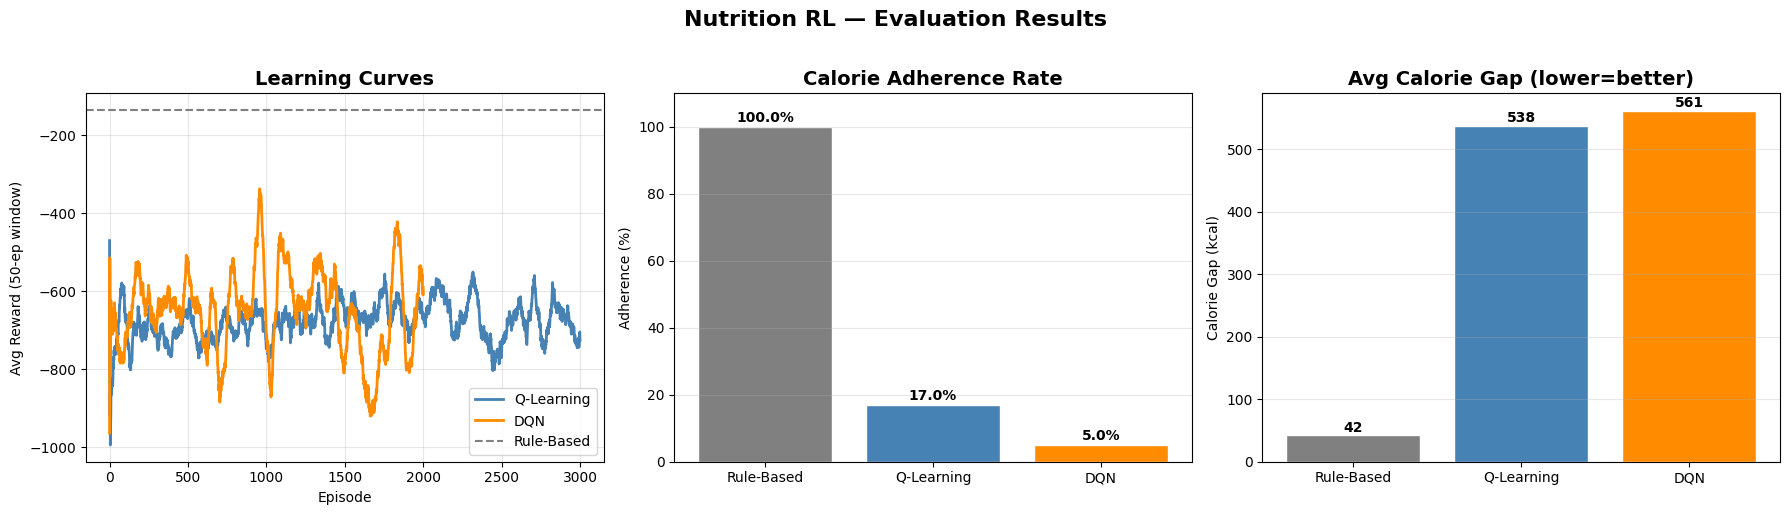

✅ Saved to Google Drive


In [23]:
def ma(data,w=50): return [np.mean(data[max(0,i-w):i+1]) for i in range(len(data))]

fig,axes=plt.subplots(1,3,figsize=(18,5))
C={'Rule-Based':'gray','Q-Learning':'steelblue','DQN':'darkorange'}

axes[0].plot(ma(ql_rewards), color='steelblue',  lw=2, label='Q-Learning')
axes[0].plot(ma(dqn_rewards),color='darkorange', lw=2, label='DQN')
axes[0].axhline(np.mean(rb_rewards[-50:]),color='gray',ls='--',lw=1.5,label='Rule-Based')
axes[0].set_title('Learning Curves',fontsize=14,fontweight='bold')
axes[0].set_xlabel('Episode');axes[0].set_ylabel('Avg Reward (50-ep window)')
axes[0].legend();axes[0].grid(alpha=0.3)

agents=['Rule-Based','Q-Learning','DQN']
adhere=[rb_m['adherence'],ql_m['adherence'],dqn_m['adherence']]
bars=axes[1].bar(agents,adhere,color=[C[a] for a in agents],edgecolor='white')
for b,v in zip(bars,adhere):
    axes[1].text(b.get_x()+b.get_width()/2,b.get_height()+0.5,f'{v:.1f}%',ha='center',va='bottom',fontweight='bold')
axes[1].set_title('Calorie Adherence Rate',fontsize=14,fontweight='bold')
axes[1].set_ylabel('Adherence (%)');axes[1].set_ylim(0,110);axes[1].grid(axis='y',alpha=0.3)

gaps=[rb_m['cal_gap'],ql_m['cal_gap'],dqn_m['cal_gap']]
bars2=axes[2].bar(agents,gaps,color=[C[a] for a in agents],edgecolor='white')
for b,v in zip(bars2,gaps):
    axes[2].text(b.get_x()+b.get_width()/2,b.get_height()+1,f'{v:.0f}',ha='center',va='bottom',fontweight='bold')
axes[2].set_title('Avg Calorie Gap (lower=better)',fontsize=14,fontweight='bold')
axes[2].set_ylabel('Calorie Gap (kcal)');axes[2].grid(axis='y',alpha=0.3)

plt.suptitle('Nutrition RL — Evaluation Results',fontsize=16,fontweight='bold',y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Recipes/nutrition_rl_results_v2.png',dpi=150,bbox_inches='tight')
plt.show()
print('✅ Saved to Google Drive')